# PE7023 - Project
## Part1.1


Diego de Miranda Gomes

Emuobosa Patience Ojoboh


In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


Reservoir engineers assure you that the inflow can be modeled with the single-phase steady-state solution of the Darcy equation for a vertical fully penetrating well:

![Equation 1](figs/eq1.png)


Plot the productivity index PI as a function of rwf.  Comment on your results.

In [2]:
## Reservoir properties
reservoir_pressure = 3800 # Pressure in psi
reservoir_temperature = 200 # Temperature in °F
k = 40 # Permeability in mD
h = 150 # Thickness in ft
re = 372 # Drainage radius in ft
S = 0 # Skin factor
API = 45 # API gravity
muo = 0.902 # Viscosity in cp
gas_specific_gravity = 0.6636 # Gas specific gravity
GOR = 800 # Gas-oil ratio in scf/STB
Pb = 3800 # Bubble point pressure in psi
Bo = 1.2 # Formation volume factor in bbl/STB
max_field_rate = 45000
number_of_wells = 7
max_rate_per_well = max_field_rate / number_of_wells

In [3]:
#Load casing data
wellbore_casing = pd.read_csv('datasets/api_casing_table_full_clean.csv')
## Collumn 'Size (in)' has values like '4 1/2', we need to convert them to decimal
wellbore_casing['Size (in) decimal'] = wellbore_casing['Size (in)'].apply(lambda x: eval(x.replace(' ', '+')))
wellbore_casing_external_diameter = wellbore_casing[['Size (in)', 'Size (in) decimal']].copy()
wellbore_casing_external_diameter.drop_duplicates(inplace=True)
max_diameter = 8.5
wellbore_casing_external_diameter = wellbore_casing_external_diameter[wellbore_casing_external_diameter['Size (in) decimal'] <= max_diameter]


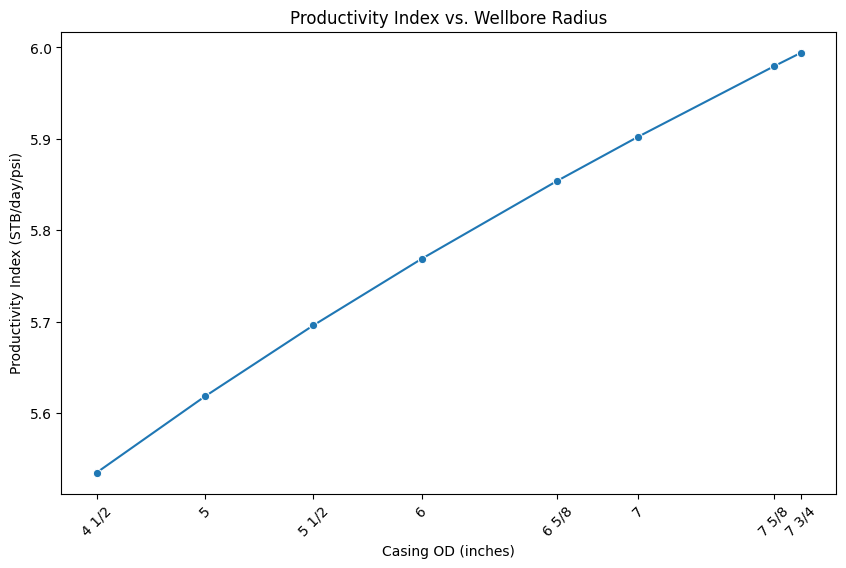

In [4]:
def PI(k, h, Bo, muo, re, rwf, S):
    # Calculate the productivity index (PI) using the given parameters
    # k: permeability (mD)
    # h: thickness of the reservoir (ft)
    # Bo: formation volume factor (bbl/STB)
    # muo: viscosity of oil (cp)
    # re: drainage radius (ft)
    # rwf: wellbore radius (ft)
    # S: skin factor

    # Convert permeability from mD to ft^2
    

    # Calculate the productivity index using the formula:
    # PI = (k * h) / (Bo * muo * (ln(re/rwf) + S))
    PI_value = (k * h) / (141.2 * Bo * muo * (np.log(re / rwf) -0.5 + S))

    return PI_value


## Evaluate different wellbore radii
wellbore_case_inches = wellbore_casing_external_diameter['Size (in) decimal'].values # Wellbore case sizes in inches
wellbore_radii = [case / 2 / 12 for case in wellbore_case_inches] # Convert to feet
PI_values = [PI(k, h, Bo, muo, re, rwf, S) for rwf in wellbore_radii]
# Plotting the results
plt.figure(figsize=(10, 6))
## Use the original 'Size (in)' for the x-axis labels but scale it using the decimal values for the x-axis positions
sns.lineplot(x=wellbore_casing_external_diameter['Size (in) decimal'], y=PI_values, marker='o')
plt.xticks(ticks=wellbore_casing_external_diameter['Size (in) decimal'], labels=wellbore_casing_external_diameter['Size (in)'])
## make x-axis labels inclined
plt.xticks(rotation=45)
plt.title('Productivity Index vs. Wellbore Radius')
plt.xlabel('Casing OD (inches)')
plt.ylabel('Productivity Index (STB/day/psi)')
plt.show()



In [5]:
# Print a table with wellbore case sizes and their corresponding productivity index values
results_df = pd.DataFrame({
    "Wellbore Case Size": wellbore_casing_external_diameter['Size (in)'],
    "Productivity Index": PI_values
})
results_df['PI Improvement (%)'] = results_df['Productivity Index']/results_df['Productivity Index'].iloc[0] * 100
print(results_df)

   Wellbore Case Size  Productivity Index  PI Improvement (%)
0               4 1/2            5.534861          100.000000
13                  5            5.618318          101.507841
24              5 1/2            5.696012          102.911562
36                  6            5.768842          104.227393
41              6 5/8            5.854084          105.767482
49                  7            5.902546          106.643065
65              7 5/8            5.979432          108.032194
77              7 3/4            5.994278          108.300417


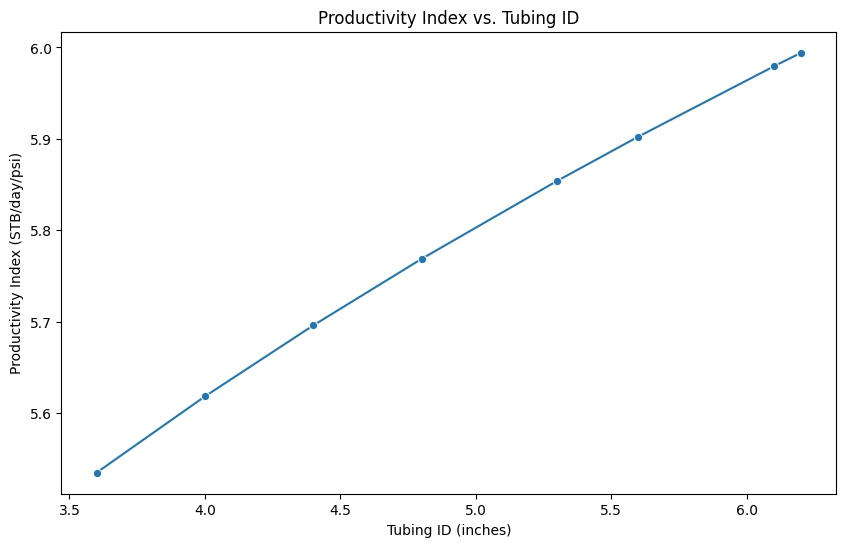

In [6]:
tubing_id = [0.8 * case for case in wellbore_case_inches] # Assuming tubing ID is 80% of the wellbore radius
## Plotiing tubing ID vs. PI
plt.figure(figsize=(10, 6))
sns.lineplot(x=tubing_id, y=PI_values, marker='o')
plt.title('Productivity Index vs. Tubing ID')
plt.xlabel('Tubing ID (inches)')
plt.ylabel('Productivity Index (STB/day/psi)')
plt.show()


In [7]:
#Show Tubing ID vs. PI in a table
data = {'Tubing ID (inches)': tubing_id, 'Productivity Index (STB/day/psi)': PI_values}
df = pd.DataFrame(data)
## Show numbers with 1 decimal place
df['Productivity Index (STB/day/psi)'] = df['Productivity Index (STB/day/psi)'].round(1)
df['PI Improvement (%)'] = df['Productivity Index (STB/day/psi)']/df['Productivity Index (STB/day/psi)'].iloc[0] * 100
df['PI Improvement (%)'] = df['PI Improvement (%)'].round(1)

print(df)


   Tubing ID (inches)  Productivity Index (STB/day/psi)  PI Improvement (%)
0                 3.6                               5.5               100.0
1                 4.0                               5.6               101.8
2                 4.4                               5.7               103.6
3                 4.8                               5.8               105.5
4                 5.3                               5.9               107.3
5                 5.6                               5.9               107.3
6                 6.1                               6.0               109.1
7                 6.2                               6.0               109.1


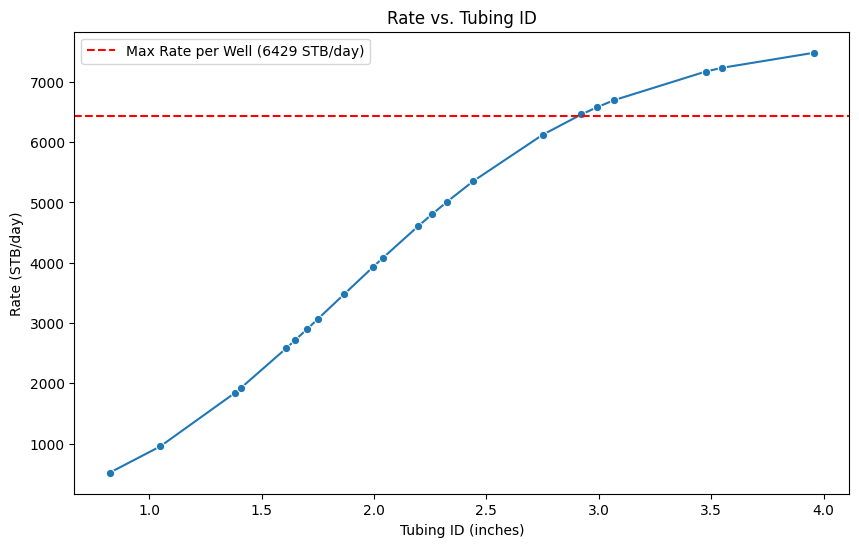

In [8]:
id_x_rate = pd.read_csv('datasets/id_x_rate.csv')
id_x_rate.columns = ['Tubing ID (inches)', 'Rate (STB/day)']
## Plotting Tubing ID vs. Rate
plt.figure(figsize=(10, 6))
sns.lineplot(x=id_x_rate['Tubing ID (inches)'], y=id_x_rate['Rate (STB/day)'], marker='o')
## Draw a horizontal line at the maximum rate per well
plt.axhline(y=max_rate_per_well, color='r', linestyle='--', label=f'Max Rate per Well ({max_rate_per_well:.0f} STB/day)')
plt.legend()
plt.title('Rate vs. Tubing ID')
plt.xlabel('Tubing ID (inches)')
plt.ylabel('Rate (STB/day)')
plt.show()


The minimum diamater to produce the max rate is 2.922, corresponding to an OD of 3.5. So the casing should have an ID minimum of 5.5. So the minimum OD is 6 5/8 (according to catalog). We decided to use a 7" casing because the difference with the highest PI is just 1.6%.

In [9]:
id_x_rate

,Tubing ID (inches),Rate (STB/day)
0,0.824,518.1336
1,1.049,954.3592
2,1.380,1838.4660
3,1.410,1930.6370
4,1.610,2582.7220
5,1.650,2719.5960
6,1.703,2901.4760
7,1.751,3069.7600
8,1.867,3477.6920
9,1.995,3926.8660


Water cut impact

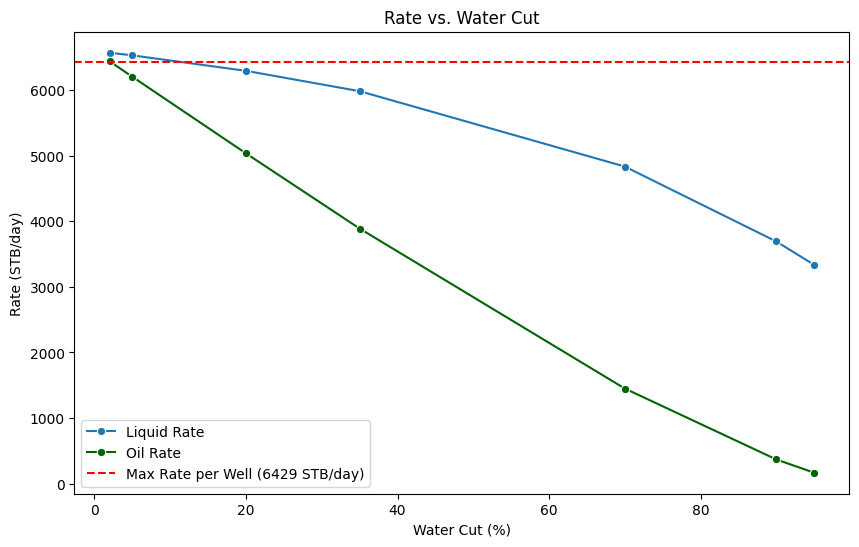

In [10]:
df_wcut = pd.read_csv('datasets/part1.1_water_cut_impact.csv')
## Plotting Water Cut vs. Rate
plt.figure(figsize=(10, 6))
df_wcut.columns = ['Water Cut (%)', 'Liquid Rate (STB/day)', 'Oil Rate (STB/day)']
sns.lineplot(x=df_wcut['Water Cut (%)'], y=df_wcut['Liquid Rate (STB/day)'], marker='o', label='Liquid Rate')
sns.lineplot(x=df_wcut['Water Cut (%)'], y=df_wcut['Oil Rate (STB/day)'], marker='o', label='Oil Rate', color='darkgreen')
# Draw a horizontal line at the maximum rate per well
plt.axhline(y=max_rate_per_well, color='r', linestyle='--', label=f'Max Rate per Well ({max_rate_per_well:.0f} STB/day)')
plt.title('Rate vs. Water Cut')
plt.xlabel('Water Cut (%)')
plt.ylabel('Rate (STB/day)')
plt.legend()
plt.show()

In [11]:
## show wcut values that produces the maximum rate per well
max_rate_row = df_wcut[df_wcut['Liquid Rate (STB/day)'] >= max_rate_per_well]['Water Cut (%)']
print(max_rate_row)


0    2
1    5
Name: Water Cut (%), dtype: int64


GLI x Wcut

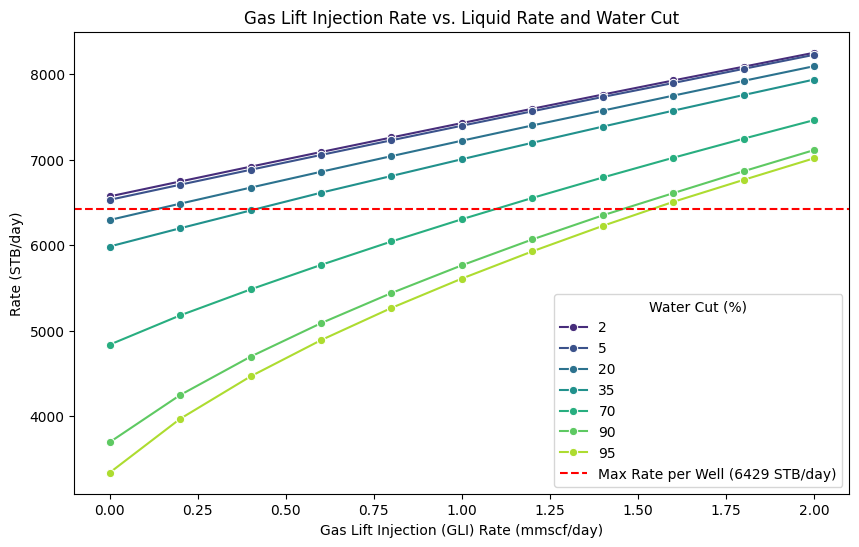

In [12]:
df_gli_wcut = pd.read_csv('datasets/part1.1_wcut_gli.csv', usecols=[0, 1, 2])
df_gli_wcut.columns = ['Gas Lift Injection (GLI) Rate (mmscf/day)', 'Liquid Rate (STB/day)', 'Water Cut (%)']
df_gli_wcut.dropna(inplace=True)
# Convert Water Cut to string so seaborn treats it as categorical
df_gli_wcut['Water Cut (%)'] = df_gli_wcut['Water Cut (%)'].astype(str)
#Plotting Gas Lift Injection Rate vs. Liquid Rate and Water cut grouping by water cut
plt.figure(figsize=(10, 6))
sns.lineplot(x=df_gli_wcut['Gas Lift Injection (GLI) Rate (mmscf/day)'], y=df_gli_wcut['Liquid Rate (STB/day)'], marker='o', hue=df_gli_wcut['Water Cut (%)'], palette='viridis')

# Draw a horizontal line at the maximum rate per well
plt.axhline(y=max_rate_per_well, color='r', linestyle='--', label=f'Max Rate per Well ({max_rate_per_well:.0f} STB/day)')
plt.title('Gas Lift Injection Rate vs. Liquid Rate and Water Cut')
plt.xlabel('Gas Lift Injection (GLI) Rate (mmscf/day)')
plt.ylabel('Rate (STB/day)')
# Get existing legend handles and labels, then recreate with title
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='Water Cut (%)')
plt.show()


In [13]:
df_gli_wcut

,Gas Lift Injection (GLI) Rate (mmscf/day),Liquid Rate (STB/day),Water Cut (%)
0,0.0,6570.797,2
1,0.2,6745.583,2
2,0.4,6918.831,2
3,0.6,7090.412,2
4,0.8,7260.610,2
...,...,...,...
72,1.2,5927.655,95
73,1.4,6226.075,95
74,1.6,6507.142,95
75,1.8,6764.781,95


In [14]:
## Create a Table showing the minimum gas lift injection rate required to maintain the maximum rate per well for each water cut
min_gli_rate_table = df_gli_wcut[df_gli_wcut['Liquid Rate (STB/day)'] >= max_rate_per_well].groupby('Water Cut (%)')['Gas Lift Injection (GLI) Rate (mmscf/day)'].min().reset_index()
min_gli_rate_table.columns = ['Water Cut (%)', 'Minimum Gas Lift Injection Rate (mmscf/day)']
## Use max_rate_row to set Gas Lift Injection Rate to 0 for water cuts that produce the maximum rate per well without gas lift
min_gli_rate_table.loc[min_gli_rate_table['Water Cut (%)'].isin(max_rate_row.astype(str)), 'Minimum Gas Lift Injection Rate (mmscf/day)'] = 0

print(min_gli_rate_table)
## Save the table to a CSV file
min_gli_rate_table.to_csv('datasets/min_gli_rate_table.csv', index=False)

  Water Cut (%)  Minimum Gas Lift Injection Rate (mmscf/day)
0             2                                          0.0
1            20                                          0.2
2            35                                          0.6
3             5                                          0.0
4            70                                          1.2
5            90                                          1.6
6            95                                          1.6


GLI x Temperature

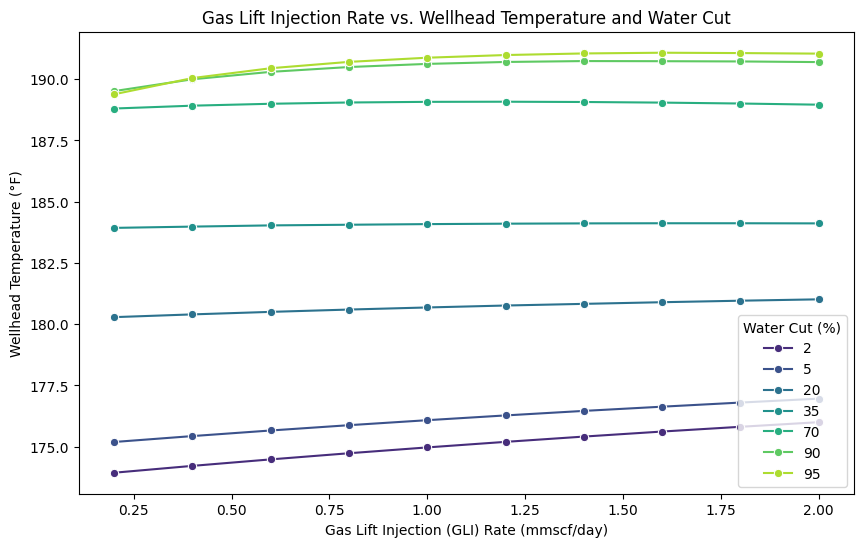

In [15]:
## Import first 3 columns of the dataset and rename them
df_gli_temp = pd.read_csv('datasets/part1.1_temperature_gli.csv', usecols=[0, 1, 2])   

df_gli_temp.columns = ['Gas Lift Injection (GLI) Rate (mmscf/day)', 'Wellhead Temperature (°F)', 'Water Cut (%)']
df_gli_temp['Water Cut (%)'] = df_gli_temp['Water Cut (%)'].astype(str)
#Plotting Gas Lift Injection Rate vs. Wellhead Temperature and Water cut grouping by water cut
plt.figure(figsize=(10, 6))
sns.lineplot(x=df_gli_temp['Gas Lift Injection (GLI) Rate (mmscf/day)'], y=df_gli_temp['Wellhead Temperature (°F)'], marker='o', hue=df_gli_temp['Water Cut (%)'], palette='viridis')

plt.title('Gas Lift Injection Rate vs. Wellhead Temperature and Water Cut')
plt.xlabel('Gas Lift Injection (GLI) Rate (mmscf/day)')
plt.ylabel('Wellhead Temperature (°F)')
# Draw legend on bottom right
plt.legend(title='Water Cut (%)', loc='lower right')
plt.show()

In [16]:
df_gli_temp[df_gli_temp['Water Cut (%)'] == '2']

,Gas Lift Injection (GLI) Rate (mmscf/day),Wellhead Temperature (°F),Water Cut (%)
0,0.2,173.9378,2
1,0.4,174.2173,2
2,0.6,174.4820,2
3,0.8,174.7329,2
4,1.0,174.9707,2
5,1.2,175.1973,2
6,1.4,175.4129,2
7,1.6,175.6184,2
8,1.8,175.8123,2
9,2.0,176.0003,2


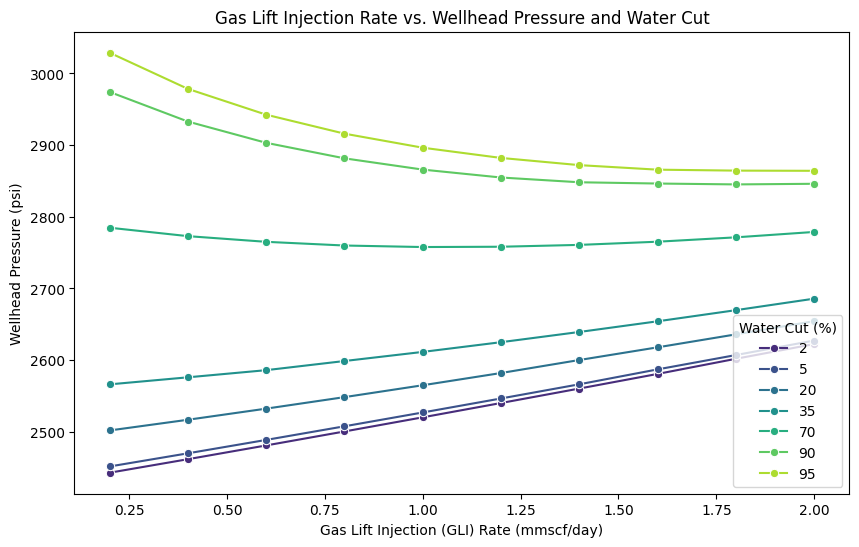

In [17]:
## Load GLI injection pressure
df_gli_pressure = pd.read_csv('datasets/part1.1_pressure_gli.csv', usecols=[0, 1, 2])
df_gli_pressure.columns = ['Gas Lift Injection (GLI) Rate (mmscf/day)', 'Wellhead Pressure (psi)', 'Water Cut (%)']
df_gli_pressure['Water Cut (%)'] = df_gli_pressure['Water Cut (%)'].astype(str)
# do not plot well head pressure = 0
df_gli_pressure = df_gli_pressure[df_gli_pressure['Wellhead Pressure (psi)'] != 0]
#Plotting Gas Lift Injection Rate vs. Wellhead Pressure and Water cut grouping by water cut
plt.figure(figsize=(10, 6))
sns.lineplot(x=df_gli_pressure['Gas Lift Injection (GLI) Rate (mmscf/day)'], y=df_gli_pressure['Wellhead Pressure (psi)'], marker='o', hue=df_gli_pressure['Water Cut (%)'], palette='viridis')
plt.title('Gas Lift Injection Rate vs. Wellhead Pressure and Water Cut')
plt.xlabel('Gas Lift Injection (GLI) Rate (mmscf/day)')
plt.ylabel('Wellhead Pressure (psi)')
# Draw legend on bottom right
plt.legend(title='Water Cut (%)', loc='lower right')
plt.show()